# **Objetivo del notebook**

El presente notebook tiene como finalidad realizar la identificación, caracterización y análisis de datos atípicos (outliers), evaluando su impacto sobre la distribución de las variables, la estructura subyacente de los datos y las relaciones estadísticas presentes en el conjunto de información.

Para ello, se implementarán y compararán diferentes metodologías de detección de observaciones atípicas, abarcando tanto enfoques clásicos como robustos, desde perspectivas univariadas y multivariadas. Adicionalmente, se analizará el efecto de dichas observaciones sobre medidas descriptivas, patrones de asociación, supuestos estadísticos y procesos posteriores de modelamiento, con el fin de establecer criterios técnicamente fundamentados para su tratamiento dentro del flujo de análisis.

## **Librerías**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import miceforest as mf
import statsmodels.api as sm
import pandas as pd
from plotly.subplots import make_subplots
import pingouin as pg
import scipy.stats as stats

from sklearn.covariance import MinCovDet
from sklearn.utils import resample
from joblib import Parallel, delayed

## **Cargar datos**

In [17]:
# ============================================================
# CARGA DE DATOS
# ============================================================

ruta = "../data/processed/nacimientos_bogota_preprocesado.csv"

df = pd.read_csv(
    ruta,
    sep=";",
    encoding="ISO-8859-1"
)

# ============================================================
# VERIFICACIÓN INICIAL
# ============================================================

print(f"Dimensiones: {df.shape}")
df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15144\1729600655.py:7: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Dimensiones: (384321, 51)


,COD_LOCALIDAD_NACIMIENTO,LOCALIDAD_NACIMIENTO,SIT_PARTO,SEXO,PESO_GRAMOS,PESO,BPN,TALLA_CENTIMETROS,ANO,ATENCION_PARTO_POR,...,PERTENENCIA_ETNICA_AGRUPADA,TIPO_DOC_MADRE_AGRUPADO,ESTADO_CONYUGAL_AGRUPADO,NIVEL_EDUCATIVO_MADRE_AGRUPADO,NIVEL_EDUCATIVO_PADRE_AGRUPADO,REGIMEN_SEGURIDAD_AGRUPADO,APGAR1_NUM,APGAR1_AGRUPADO,TIPO_PARTO_AGRUPADO,GESTACION_AGRUPADA
0,13,Teusaquillo,1.INSTITUCION DE SALUD,MASCULINO,3330.0,5.NORMAL(3000_4199),0,51,2020,1.MEDICO,...,No pertenece a grupo etnico reconocido,Colombiana identificada,Casada,Media,Media,Contributivo,8.0,Alto,CESAREA,A TERMINO
1,8,Kennedy,1.INSTITUCION DE SALUD,FEMENINO,2625.0,4.DEFICIT(2500_2999),0,47,2020,1.MEDICO,...,No pertenece a grupo etnico reconocido,Extranjera,Sin pareja,Media,Media,No asegurado,8.0,Alto,ESPONTANEO,A TERMINO
2,9,Fontibón,1.INSTITUCION DE SALUD,FEMENINO,3150.0,5.NORMAL(3000_4199),0,49,2020,1.MEDICO,...,No pertenece a grupo etnico reconocido,Colombiana identificada,Sin pareja,Basica,Media,Subsidiado,9.0,Alto,ESPONTANEO,A TERMINO
3,2,Chapinero,1.INSTITUCION DE SALUD,MASCULINO,4475.0,6.EXCESO(MAS4200),0,54,2020,1.MEDICO,...,No pertenece a grupo etnico reconocido,Colombiana identificada,Union libre,Superior,Superior,Contributivo,9.0,Alto,CESAREA,A TERMINO
4,12,Barrios Unidos,1.INSTITUCION DE SALUD,FEMENINO,2380.0,3.BAJO(1500_2499),1,48,2020,1.MEDICO,...,No pertenece a grupo etnico reconocido,Colombiana identificada,Union libre,Media,Media,Contributivo,8.0,Alto,ESPONTANEO,A TERMINO


### **Variables cualitativas**

In [18]:
variables_cuantitativas= ['PESO_GRAMOS',  'NUM_CONSULTAS_PRENAT',
                          'EDAD_MADRE',   'NUM_HIJOS_NACIDOS_VIVOS',
                          'NUM_EMBARAZOS', 'EDAD_PADRE', 'TIEMPO_GESTACION', 'TALLA_CENTIMETROS'] 

## **Caracterización de outliers vía tukey**

Se realizó una evaluación univariada de valores atípicos sobre las principales variables cuantitativas del estudio utilizando el método de Tukey basado en rango intercuartílico (IQR). Para cada variable se calcularon el primer cuartil (Q1), el tercer cuartil (Q3) y el IQR (`Q3 - Q1`), definiendo como límites de atipicidad:

* Límite inferior: `Q1 - 1.5 × IQR`
* Límite superior: `Q3 + 1.5 × IQR`

A partir de estos límites, cada observación fue clasificada en una de las siguientes categorías:

* `T`: valor típico,
* `AI`: atípico inferior,
* `AS`: atípico superior,
* `F`: valor faltante.

Posteriormente, se construyó un subconjunto (`atipic_uni`) que contiene únicamente individuos con al menos un valor atípico, permitiendo identificar tanto el número total de variables atípicas por individuo como las variables específicas donde ocurrió la atipicidad.

Finalmente, se generó una caracterización global por variable, cuantificando el número y proporción de valores típicos, faltantes, atípicos inferiores y atípicos superiores. Este análisis permitió evaluar la magnitud y distribución de los valores extremos antes de aplicar procedimientos de imputación y winsorización.

In [19]:
# ============================================================
# CLASIFICACIÓN Y CARACTERIZACIÓN DE VALORES ATÍPICOS
# Método de Tukey: Q1 - 1.5*IQR / Q3 + 1.5*IQR
# ============================================================
variables_cuantitativas= ['PESO_GRAMOS',  'NUM_CONSULTAS_PRENAT',
                          'EDAD_MADRE', 'ULTIMO_CURSO_APROBADO_MADRE',  'NUM_HIJOS_NACIDOS_VIVOS',
                          'NUM_EMBARAZOS', 'EDAD_PADRE', 'ULTIMO_CURSO_APROBADO_PADRE', 'TIEMPO_GESTACION', 'TALLA_CENTIMETROS'] 

# Conservar solo variables existentes
variables_cuantitativas = [
    v for v in variables_cuantitativas
    if v in df.columns
]

# ============================================================
#  CREAR CATEGORÍAS DE ATIPICIDAD
# F  = faltante
# AI = atípico inferior
# AS = atípico superior
# T  = típico
# ============================================================

df_1 = df.copy()

for variable in variables_cuantitativas:

    serie = pd.to_numeric(df_1[variable], errors="coerce")

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    condiciones = [
        serie.isna(),
        serie < limite_inferior,
        serie > limite_superior
    ]

    valores = ["F", "AI", "AS"]

    df_1[f"{variable}_categoria"] = np.select(
        condiciones,
        valores,
        default="T"
    )

# ============================================================
#  DATAFRAME DE OBSERVACIONES CON AL MENOS UN ATÍPICO
# ============================================================

cat_cols = [f"{v}_categoria" for v in variables_cuantitativas]

mask_atipico = df_1[cat_cols].isin(["AI", "AS"]).any(axis=1)

atipic_uni = df_1.loc[mask_atipico].copy()

# Número de variables atípicas por fila
atipic_uni["n_atipicos"] = (
    atipic_uni[cat_cols]
    .isin(["AI", "AS"])
    .sum(axis=1)
)

# Lista de variables atípicas por fila
def listar_atipicos(row):
    return ", ".join(
        f"{v}({row[f'{v}_categoria']})"
        for v in variables_cuantitativas
        if row[f"{v}_categoria"] in ["AI", "AS"]
    )

atipic_uni["atipico_en"] = atipic_uni.apply(
    listar_atipicos,
    axis=1
)

# Orden final intercalado variable + categoría
orden_intercalado = ["pk_id_anom"]

for v in variables_cuantitativas:
    orden_intercalado.extend([v, f"{v}_categoria"])

orden_intercalado += ["n_atipicos", "atipico_en"]

orden_intercalado = [
    c for c in orden_intercalado
    if c in atipic_uni.columns
]

atipic_uni = (
    atipic_uni[orden_intercalado]
    .reset_index(drop=True)
)

# ============================================================
#  CARACTERIZACIÓN GLOBAL DE ATÍPICOS POR VARIABLE
# ============================================================

resumen_atipicos = []

for variable in variables_cuantitativas:

    col_cat = f"{variable}_categoria"
    conteos = df_1[col_cat].value_counts(dropna=False)

    n_ai = conteos.get("AI", 0)
    n_as = conteos.get("AS", 0)
    n_f = conteos.get("F", 0)
    n_t = conteos.get("T", 0)

    total = len(df_1)
    total_atipicos = n_ai + n_as

    resumen_atipicos.append({
        "variable": variable,
        "tipicos": n_t,
        "faltantes": n_f,
        "atipicos_inferiores": n_ai,
        "atipicos_superiores": n_as,
        "total_atipicos": total_atipicos,
        "prop_atipicos_inferiores": round(n_ai / total, 3),
        "prop_atipicos_superiores": round(n_as / total, 3),
        "prop_atipicos_total": round(total_atipicos / total, 3),
        "prop_faltantes": round(n_f / total, 3)
    })

df_caracterizacion = (
    pd.DataFrame(resumen_atipicos)
    .sort_values("total_atipicos", ascending=False)
    .reset_index(drop=True)
)

# ============================================================
#  RESULTADOS
# ============================================================

print("Total registros en df:", df.shape[0])
print("Registros con al menos un atípico:", atipic_uni.shape[0])
print("Variables evaluadas:", len(variables_cuantitativas))

#display(df_caracterizacion)
#display(atipic_uni)

# ============================================================
# DATASET SIN ATÍPICOS
# Elimina registros con al menos un AI o AS
# Conserva faltantes (F)
# ============================================================

mask_sin_atipicos = ~(
    df_1[cat_cols]
    .isin(["AI", "AS"])
    .any(axis=1)
)

df_sin_atipicos = (
    df_1.loc[mask_sin_atipicos]
    .copy()
)

print("\n======================================")
print("DATASET SIN ATÍPICOS")
print("======================================")
print("Registros originales:", len(df_1))
print("Registros eliminados:", len(df_1) - len(df_sin_atipicos))
print("Registros finales:", len(df_sin_atipicos))
print(
    "Porcentaje eliminado:",
    round(
        (len(df_1) - len(df_sin_atipicos))
        / len(df_1) * 100,
        2
    ),
    "%"
)

print("Total registros en df sin atípicos:", df_sin_atipicos.shape[0])
print("dataset sin atípicos:", df_sin_atipicos.to_csv("../data/processed/nacimientos_bogota_preprocesado_sin_atipicos_univariados.csv", index=False, sep=";", encoding="ISO-8859-1"))

Total registros en df: 384321
Registros con al menos un atípico: 72055
Variables evaluadas: 10

DATASET SIN ATÍPICOS
Registros originales: 384321
Registros eliminados: 72055
Registros finales: 312266
Porcentaje eliminado: 18.75 %
Total registros en df sin atípicos: 312266
dataset sin atípicos: None


### Tratamiento robusto de variables cuantitativas para modelamiento del peso al nacer

Este bloque implementa un proceso sistemático de depuración, imputación y control de valores extremos sobre las variables cuantitativas utilizadas en el análisis. El objetivo principal es mejorar la calidad de los datos antes del modelamiento estadístico, preservando la coherencia clínica de las variables y reduciendo la influencia de registros atípicos potencialmente derivados de errores de captura, digitación o codificación administrativa.

Inicialmente se identifican las variables cuantitativas de interés y se convierten explícitamente a formato numérico. Posteriormente, diversos códigos administrativos utilizados para representar información desconocida o no disponible (por ejemplo, valores como 99 o 9999) son recodificados como valores faltantes (`NaN`) para evitar que sean interpretados erróneamente como observaciones reales.

La variable objetivo del estudio (`PESO_GRAMOS`) se excluye deliberadamente de cualquier procedimiento de imputación o winsorización, con el fin de preservar íntegramente la distribución observada del desenlace.

A continuación, para cada variable explicativa cuantitativa se calculan límites de detección de valores extremos utilizando la regla de Tukey basada en el rango intercuartílico (IQR):

$$
IQR = Q_3 - Q_1
$$

$$
LI = Q_1 - 1.5 \times IQR
$$

$$
LS = Q_3 + 1.5 \times IQR
$$

donde (Q_1) y (Q_3) corresponden al primer y tercer cuartil respectivamente.

Para variables de conteo, los límites obtenidos se ajustan a valores enteros mediante redondeo superior, garantizando consistencia con la naturaleza discreta de estas mediciones.

Los valores faltantes de las variables explicativas son posteriormente imputados utilizando la mediana observada de cada variable, una estrategia robusta frente a distribuciones asimétricas y presencia de valores extremos.

Después de la imputación se aplica un proceso de winsorización. Este procedimiento reemplaza observaciones ubicadas fuera de los límites establecidos por Tukey por el valor del límite correspondiente. Para variables con asimetría positiva esperada (por ejemplo, número de consultas prenatales o número de embarazos) únicamente se restringe la cola superior de la distribución, mientras que para el resto de variables se controlan ambas colas.

Adicionalmente se generan indicadores auxiliares (*flags*) que registran la ocurrencia de valores faltantes y observaciones originalmente ubicadas fuera de los límites definidos. Estos indicadores permiten mantener trazabilidad sobre las transformaciones realizadas y facilitan posteriores análisis de sensibilidad o auditoría de calidad de datos.

Finalmente, se construyen resúmenes diagnósticos que documentan los límites utilizados, la cantidad de observaciones imputadas por variable, el porcentaje de datos faltantes tratado y la presencia residual de valores fuera de rango tras el proceso de limpieza. El resultado es un conjunto de datos cuantitativos depurado, consistente y preparado para etapas posteriores de análisis exploratorio y modelamiento predictivo.


In [20]:

# ============================================================
# VARIABLES CUANTITATIVAS
# ============================================================

variables_cuantitativas = [
    "PESO_GRAMOS",
    "NUM_CONSULTAS_PRENAT",
    "EDAD_MADRE",
    "NUM_HIJOS_NACIDOS_VIVOS",
    "NUM_EMBARAZOS",
    "EDAD_PADRE",
    "TIEMPO_GESTACION",
    "TALLA_CENTIMETROS"
]

variables_cuantitativas = [
    v for v in variables_cuantitativas
    if v in df.columns
]

# ============================================================
# VARIABLE OBJETIVO
# NO SE IMPUTA NI SE WINSORIZA
# ============================================================

variable_objetivo = "PESO_GRAMOS"

# ============================================================
# VARIABLES CON COLA DERECHA ESPERADA
# ============================================================

asimetria = {
    "NUM_CONSULTAS_PRENAT": "up",
    "NUM_HIJOS_NACIDOS_VIVOS": "up",
    "NUM_EMBARAZOS": "up"
}

# ============================================================
# VARIABLES DE CONTEO
# ============================================================

variables_conteo = [
    "NUM_CONSULTAS_PRENAT",
    "NUM_HIJOS_NACIDOS_VIVOS",
    "NUM_EMBARAZOS"
]

# ============================================================
# CÓDIGOS ADMINISTRATIVOS A TRATAR COMO NA
# ============================================================

codigos_na = {
    "ULTIMO_CURSO_APROBADO_MADRE": [99],
    "ULTIMO_CURSO_APROBADO_PADRE": [99],
    "PESO_GRAMOS": [9999],
    "TALLA_CENTIMETROS": [99],
    "NUM_HIJOS_NACIDOS_VIVOS": [99],
    "NUM_CONSULTAS_PRENAT": [99],
    "NUM_EMBARAZOS": [99],
}

# ============================================================
# COPIA DE TRABAJO
# ============================================================

df_base = df.copy()

# ============================================================
# CONVERSIÓN A NUMÉRICO
# ============================================================

for col in variables_cuantitativas:

    df_base[col] = pd.to_numeric(
        df_base[col],
        errors="coerce"
    )

# ============================================================
# REEMPLAZAR CÓDIGOS ADMINISTRATIVOS POR NaN
# ============================================================

for col, valores in codigos_na.items():

    if col not in df_base.columns:
        continue

    df_base[col] = df_base[col].replace(
        valores,
        np.nan
    )

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def calcular_limites_tukey(
    df,
    variables,
    k=1.5,
    asimetria=None
):
    "Calcula límites de Tukey para una lista de variables en un DataFrame."

    registros = []

    for col in variables:

        serie = (
            pd.to_numeric(df[col], errors="coerce")
            .dropna()
        )

        modo = (asimetria or {}).get(
            col,
            "both"
        )

        if len(serie) == 0:

            registros.append({
                "variable": col,
                "q1": np.nan,
                "q3": np.nan,
                "iqr": np.nan,
                "limite_inferior": np.nan,
                "limite_superior": np.nan,
                "mediana_imputacion": np.nan,
                "asimetria": modo
            })

            continue

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)

        iqr = q3 - q1

        registros.append({
            "variable": col,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": q1 - k * iqr,
            "limite_superior": q3 + k * iqr,
            "mediana_imputacion": serie.median(),
            "asimetria": modo
        })

    return (
        pd.DataFrame(registros)
        .set_index("variable")
    )


def ajustar_limites_conteo(
    limites,
    variables_conteo
):
    """Ajusta los límites de Tukey para variables de conteo, redondeando hacia arriba"""

    limites = limites.copy()

    for col in variables_conteo:

        if col not in limites.index:
            continue

        limites.loc[col, "limite_inferior"] = np.ceil(
            limites.loc[col, "limite_inferior"]
        )

        limites.loc[col, "limite_superior"] = np.ceil(
            limites.loc[col, "limite_superior"]
        )

    return limites


def imputar_winsorizar(
    df,
    limites,
    variable_objetivo=None,
    crear_flags=True,
    aplicar_winsorizacion=True
):
    "Imputa valores faltantes y opcionalmente winsoriza según límites de Tukey. Crea flags de imputación y atipicidad si se indica."

    df_proc = df.copy()

    for col, row in limites.iterrows():

        if col not in df_proc.columns:
            continue

        serie_original = pd.to_numeric(
            df_proc[col],
            errors="coerce"
        )

        low = row["limite_inferior"]
        high = row["limite_superior"]
        mediana = row["mediana_imputacion"]

        modo = str(
            row["asimetria"]
        ).lower()

        # -----------------------------------
        # FLAGS
        # -----------------------------------

        if crear_flags:

            df_proc[f"{col}_missing"] = (
                serie_original.isna()
                .astype(int)
            )

            df_proc[f"{col}_out_low"] = (
                (serie_original < low)
                .astype(int)
                if np.isfinite(low)
                else 0
            )

            df_proc[f"{col}_out_high"] = (
                (serie_original > high)
                .astype(int)
                if np.isfinite(high)
                else 0
            )

        # -----------------------------------
        # VARIABLE OBJETIVO
        # NO IMPUTAR
        # NO WINSORIZAR
        # -----------------------------------

        if col == variable_objetivo:

            df_proc[col] = serie_original

            continue

        # -----------------------------------
        # IMPUTACIÓN
        # -----------------------------------

        df_proc[col] = serie_original.fillna(
            mediana
        )

        # -----------------------------------
        # WINSORIZACIÓN (OPCIONAL)
        # -----------------------------------

        if aplicar_winsorizacion:

            if modo in ["both", "down"]:

                df_proc.loc[
                    df_proc[col] < low,
                    col
                ] = low

            if modo in ["both", "up"]:

                df_proc.loc[
                    df_proc[col] > high,
                    col
                ] = high

    return df_proc


def resumen_post_winsorizacion(
    df_proc,
    limites,
    variable_objetivo=None
):

    resumen = []

    for col, row in limites.iterrows():

        serie = pd.to_numeric(
            df_proc[col],
            errors="coerce"
        )

        low = row["limite_inferior"]
        high = row["limite_superior"]

        n_low = (
            (serie < low).sum()
            if np.isfinite(low)
            else 0
        )

        n_high = (
            (serie > high).sum()
            if np.isfinite(high)
            else 0
        )

        resumen.append({
            "variable": col,
            "variable_objetivo": col == variable_objetivo,
            "fuera_limite_inferior": int(n_low),
            "fuera_limite_superior": int(n_high),
            "total_fuera_limites": int(
                n_low + n_high
            )
        })

    return pd.DataFrame(resumen)

# ============================================================
# VARIABLES A PROCESAR
# EXCLUYENDO LA VARIABLE OBJETIVO
# ============================================================

variables_modelado = [
    v
    for v in variables_cuantitativas
    if v != variable_objetivo
]

# ============================================================
# LÍMITES TUKEY
# ============================================================

limites_tukey = calcular_limites_tukey(
    df=df_base,
    variables=variables_modelado,
    k=1.5,
    asimetria=asimetria
)

limites_tukey = ajustar_limites_conteo(
    limites_tukey,
    variables_conteo
)

# ============================================================
# IMPUTACIÓN + WINSORIZACIÓN
# ============================================================

# ============================================================
# DATASET SOLO IMPUTADO
# ============================================================

df_imputado = imputar_winsorizar(
    df=df_base,
    limites=limites_tukey,
    variable_objetivo=variable_objetivo,
    crear_flags=True,
    aplicar_winsorizacion=False
)

# ============================================================
# DATASET IMPUTADO + WINSORIZADO
# ============================================================

df_limpio = imputar_winsorizar(
    df=df_base,
    limites=limites_tukey,
    variable_objetivo=variable_objetivo,
    crear_flags=True,
    aplicar_winsorizacion=True
)

print("Dimensión dataset imputado:", df_imputado.shape)
print("Dimensión dataset limpio:", df_limpio.shape)

# ============================================================
# VALIDACIÓN
# ============================================================

resumen_post = resumen_post_winsorizacion(
    df_limpio,
    limites_tukey,
    variable_objetivo
)

print("\nLÍMITES TUKEY")
display(
    limites_tukey.round(3)
)

print("\nRESUMEN POSTERIOR")
display(resumen_post)

# ============================================================
# RESUMEN DE IMPUTACIÓN
# ============================================================

resumen_imputacion = []

for col in variables_modelado:

    n_missing = (
        df_base[col]
        .isna()
        .sum()
    )

    resumen_imputacion.append({
        "variable": col,
        "n_imputados": n_missing,
        "porcentaje_imputado":
            round(
                n_missing /
                len(df_base) * 100,
                3
            ),
        "mediana_imputacion":
            round(
                limites_tukey.loc[
                    col,
                    "mediana_imputacion"
                ],
                3
            )
    })

df_resumen_imputacion = (
    pd.DataFrame(
        resumen_imputacion
    )
    .sort_values(
        "porcentaje_imputado",
        ascending=False
    )
)

print("\nRESUMEN DE IMPUTACIÓN")
display(df_resumen_imputacion)

print("\nDimensión original:", df.shape)
print("Dimensión procesada:", df_limpio.shape)
df_imputado.to_csv("../data/processed/nacimientos_bogota_preprocesado_v2_imputados_con_outliers.csv", index=False, sep=";", encoding="ISO-8859-1")
df_limpio.to_csv("../data/processed/nacimientos_bogota_preprocesado_v2_imputados_winsorizados.csv", index=False, sep=";", encoding="ISO-8859-1")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15144\3689351902.py:262: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '9.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_proc.loc[


Dimensión dataset imputado: (384321, 72)
Dimensión dataset limpio: (384321, 72)

LÍMITES TUKEY


,q1,q3,iqr,limite_inferior,limite_superior,mediana_imputacion,asimetria
variable,,,,,,,
NUM_CONSULTAS_PRENAT,5.0,8.0,3.0,1.0,13.0,7.0,up
EDAD_MADRE,23.0,32.0,9.0,9.5,45.5,28.0,both
NUM_HIJOS_NACIDOS_VIVOS,1.0,2.0,1.0,-0.0,4.0,1.0,up
NUM_EMBARAZOS,1.0,2.0,1.0,-0.0,4.0,2.0,up
EDAD_PADRE,25.0,36.0,11.0,8.5,52.5,30.0,both
TIEMPO_GESTACION,37.0,39.0,2.0,34.0,42.0,38.0,both
TALLA_CENTIMETROS,48.0,51.0,3.0,43.5,55.5,50.0,both



RESUMEN POSTERIOR


,variable,variable_objetivo,fuera_limite_inferior,fuera_limite_superior,total_fuera_limites
0,NUM_CONSULTAS_PRENAT,False,16754,0,16754
1,EDAD_MADRE,False,0,0,0
2,NUM_HIJOS_NACIDOS_VIVOS,False,0,0,0
3,NUM_EMBARAZOS,False,0,0,0
4,EDAD_PADRE,False,0,0,0
5,TIEMPO_GESTACION,False,0,0,0
6,TALLA_CENTIMETROS,False,0,0,0



RESUMEN DE IMPUTACIÓN


,variable,n_imputados,porcentaje_imputado,mediana_imputacion
4,EDAD_PADRE,3806,0.990,30.0
3,NUM_EMBARAZOS,3279,0.853,2.0
2,NUM_HIJOS_NACIDOS_VIVOS,3275,0.852,1.0
5,TIEMPO_GESTACION,113,0.029,38.0
6,TALLA_CENTIMETROS,88,0.023,50.0
0,NUM_CONSULTAS_PRENAT,39,0.010,7.0
1,EDAD_MADRE,0,0.000,28.0



Dimensión original: (384321, 51)
Dimensión procesada: (384321, 72)


## **Análisis de sensibilidad frente al tratamiento de datos faltantes y valores extremos**

In [21]:
# ============================================================
# DESCRIPTIVOS COMPARATIVOS
# df, df_limpio y df_sin_atipicos
# ============================================================

datasets = {
    "Original": df,
    "Limpio": df_limpio,
    "Imputado": df_imputado,
    "Sin_atipicos": df_sin_atipicos
}

resumen_descriptivo = []

for nombre, datos in datasets.items():

    desc = (
        datos[variables_cuantitativas]
        .describe()
        .T
        .reset_index()
        .rename(columns={"index": "variable"})
    )

    desc["dataset"] = nombre

    resumen_descriptivo.append(desc)

resumen_descriptivo = pd.concat(
    resumen_descriptivo,
    ignore_index=True
)

# Reordenar columnas
cols = [
    "dataset",
    "variable",
    "count",
    "mean",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
]

resumen_descriptivo = resumen_descriptivo[cols]

display(resumen_descriptivo)

,dataset,variable,count,mean,std,min,25%,50%,75%,max
0,Original,PESO_GRAMOS,384320.0,2936.476585,507.967693,345.0,2680.0,2980.0,3255.0,9999.0
1,Original,NUM_CONSULTAS_PRENAT,384321.0,6.664057,3.074439,0.0,5.0,7.0,8.0,99.0
2,Original,EDAD_MADRE,384321.0,27.876710,6.318831,11.0,23.0,28.0,32.0,54.0
3,Original,NUM_HIJOS_NACIDOS_VIVOS,381047.0,1.697463,0.899549,1.0,1.0,1.0,2.0,99.0
4,Original,NUM_EMBARAZOS,381047.0,1.916333,1.139519,1.0,1.0,2.0,2.0,99.0
5,Original,EDAD_PADRE,380515.0,30.883237,7.571711,0.0,25.0,30.0,36.0,80.0
6,Original,TIEMPO_GESTACION,384208.0,38.017150,1.906626,20.0,37.0,38.0,39.0,43.0
7,Original,TALLA_CENTIMETROS,384321.0,49.218846,2.937924,17.0,48.0,50.0,51.0,99.0
8,Limpio,PESO_GRAMOS,384244.0,2935.079681,498.211374,345.0,2680.0,2980.0,3255.0,5325.0
9,Limpio,NUM_CONSULTAS_PRENAT,384321.0,6.615977,2.814493,0.0,5.0,7.0,8.0,13.0


In [22]:
datasets = {
    "Original": df,
    "Limpio": df_limpio,
    "Imputado": df_imputado,
    "Sin_atipicos": df_sin_atipicos
}

for nombre, datos in datasets.items():

    # ---------------------------------------
    # Variables numéricas disponibles
    # ---------------------------------------

    vars_disp = [
        v for v in variables_cuantitativas
        if v in datos.columns
    ]

    # ---------------------------------------
    # Correlación de Pearson
    # ---------------------------------------

    corr = (
        datos[vars_disp]
        .corr(method="pearson")
    )

    print(f"\nCorrelación de Pearson - {nombre}")
    display(corr.round(3))


Correlación de Pearson - Original


,PESO_GRAMOS,NUM_CONSULTAS_PRENAT,EDAD_MADRE,NUM_HIJOS_NACIDOS_VIVOS,NUM_EMBARAZOS,EDAD_PADRE,TIEMPO_GESTACION,TALLA_CENTIMETROS
PESO_GRAMOS,1.000,0.099,0.033,0.007,0.017,0.026,0.729,0.810
NUM_CONSULTAS_PRENAT,0.099,1.000,0.304,-0.113,-0.070,0.222,0.092,0.043
EDAD_MADRE,0.033,0.304,1.000,0.337,0.354,0.642,-0.028,-0.015
NUM_HIJOS_NACIDOS_VIVOS,0.007,-0.113,0.337,1.000,0.820,0.238,-0.056,0.002
NUM_EMBARAZOS,0.017,-0.070,0.354,0.820,1.000,0.248,-0.046,0.006
EDAD_PADRE,0.026,0.222,0.642,0.238,0.248,1.000,-0.015,-0.011
TIEMPO_GESTACION,0.729,0.092,-0.028,-0.056,-0.046,-0.015,1.000,0.713
TALLA_CENTIMETROS,0.810,0.043,-0.015,0.002,0.006,-0.011,0.713,1.000



Correlación de Pearson - Limpio


,PESO_GRAMOS,NUM_CONSULTAS_PRENAT,EDAD_MADRE,NUM_HIJOS_NACIDOS_VIVOS,NUM_EMBARAZOS,EDAD_PADRE,TIEMPO_GESTACION,TALLA_CENTIMETROS
PESO_GRAMOS,1.000,0.109,0.033,0.010,0.024,0.035,0.693,0.775
NUM_CONSULTAS_PRENAT,0.109,1.000,0.322,-0.126,-0.079,0.241,0.082,0.024
EDAD_MADRE,0.033,0.322,1.000,0.343,0.375,0.654,-0.033,-0.016
NUM_HIJOS_NACIDOS_VIVOS,0.010,-0.126,0.343,1.000,0.847,0.252,-0.067,0.008
NUM_EMBARAZOS,0.024,-0.079,0.375,0.847,1.000,0.273,-0.056,0.014
EDAD_PADRE,0.035,0.241,0.654,0.252,0.273,1.000,-0.019,-0.001
TIEMPO_GESTACION,0.693,0.082,-0.033,-0.067,-0.056,-0.019,1.000,0.614
TALLA_CENTIMETROS,0.775,0.024,-0.016,0.008,0.014,-0.001,0.614,1.000



Correlación de Pearson - Imputado


,PESO_GRAMOS,NUM_CONSULTAS_PRENAT,EDAD_MADRE,NUM_HIJOS_NACIDOS_VIVOS,NUM_EMBARAZOS,EDAD_PADRE,TIEMPO_GESTACION,TALLA_CENTIMETROS
PESO_GRAMOS,1.000,0.103,0.033,0.008,0.020,0.034,0.732,0.806
NUM_CONSULTAS_PRENAT,0.103,1.000,0.319,-0.128,-0.082,0.233,0.095,0.042
EDAD_MADRE,0.033,0.319,1.000,0.340,0.370,0.638,-0.028,-0.017
NUM_HIJOS_NACIDOS_VIVOS,0.008,-0.128,0.340,1.000,0.845,0.243,-0.055,0.004
NUM_EMBARAZOS,0.020,-0.082,0.370,0.845,1.000,0.261,-0.047,0.008
EDAD_PADRE,0.034,0.233,0.638,0.243,0.261,1.000,-0.015,-0.001
TIEMPO_GESTACION,0.732,0.095,-0.028,-0.055,-0.047,-0.015,1.000,0.721
TALLA_CENTIMETROS,0.806,0.042,-0.017,0.004,0.008,-0.001,0.721,1.000



Correlación de Pearson - Sin_atipicos


,PESO_GRAMOS,NUM_CONSULTAS_PRENAT,EDAD_MADRE,NUM_HIJOS_NACIDOS_VIVOS,NUM_EMBARAZOS,EDAD_PADRE,TIEMPO_GESTACION,TALLA_CENTIMETROS
PESO_GRAMOS,1.000,0.074,0.052,0.029,0.041,0.049,0.575,0.700
NUM_CONSULTAS_PRENAT,0.074,1.000,0.324,-0.066,-0.036,0.248,0.043,-0.006
EDAD_MADRE,0.052,0.324,1.000,0.307,0.327,0.676,-0.027,-0.009
NUM_HIJOS_NACIDOS_VIVOS,0.029,-0.066,0.307,1.000,0.838,0.242,-0.064,0.013
NUM_EMBARAZOS,0.041,-0.036,0.327,0.838,1.000,0.254,-0.051,0.018
EDAD_PADRE,0.049,0.248,0.676,0.242,0.254,1.000,-0.019,0.003
TIEMPO_GESTACION,0.575,0.043,-0.027,-0.064,-0.051,-0.019,1.000,0.487
TALLA_CENTIMETROS,0.700,-0.006,-0.009,0.013,0.018,0.003,0.487,1.000


A partir del análisis univariado realizado sobre las variables cuantitativas, se seleccionó el conjunto de datos **df_limpio** como base para los análisis posteriores debido a que representa el mejor equilibrio entre calidad de los datos, robustez estadística y preservación de la información. En comparación con el conjunto original, la estrategia aplicada permitió corregir valores faltantes mediante imputación robusta por mediana y reducir la influencia de observaciones extremas mediante winsorización basada en los límites de Tukey, sin eliminar registros de la muestra. Adicionalmente, el análisis descriptivo y las matrices de correlación mostraron que la estructura de asociación entre variables se conserva de forma adecuada, mientras que la eliminación completa de atípicos (**df_sin_atipicos**) genera una pérdida importante de observaciones y una disminución apreciable en relaciones epidemiológicamente relevantes, particularmente aquellas asociadas al peso al nacer, la edad gestacional y la talla neonatal. Por su parte, el conjunto únicamente imputado (**df_imputado**) mantiene la totalidad de los valores extremos, conservando posibles observaciones con capacidad de distorsionar estimaciones posteriores. En consecuencia, **df_limpio** permite trabajar con una base más estable y robusta, preservando simultáneamente la variabilidad inherente al fenómeno y la representatividad de la población analizada.

In [23]:
# ============================================================
# ELIMINAR FLAGS Y VARIABLES AUXILIARES
# ============================================================

cols_eliminar = [
    'NUM_CONSULTAS_PRENAT_missing',
    'NUM_CONSULTAS_PRENAT_out_low',
    'NUM_CONSULTAS_PRENAT_out_high',

    'EDAD_MADRE_missing',
    'EDAD_MADRE_out_low',
    'EDAD_MADRE_out_high',

    'ULTIMO_CURSO_APROBADO_MADRE_missing',
    'ULTIMO_CURSO_APROBADO_MADRE_out_low',
    'ULTIMO_CURSO_APROBADO_MADRE_out_high',

    'NUM_HIJOS_NACIDOS_VIVOS_missing',
    'NUM_HIJOS_NACIDOS_VIVOS_out_low',
    'NUM_HIJOS_NACIDOS_VIVOS_out_high',

    'NUM_EMBARAZOS_missing',
    'NUM_EMBARAZOS_out_low',
    'NUM_EMBARAZOS_out_high',

    'EDAD_PADRE_missing',
    'EDAD_PADRE_out_low',
    'EDAD_PADRE_out_high',

    'ULTIMO_CURSO_APROBADO_PADRE_missing',
    'ULTIMO_CURSO_APROBADO_PADRE_out_low',
    'ULTIMO_CURSO_APROBADO_PADRE_out_high',

    'TIEMPO_GESTACION_missing',
    'TIEMPO_GESTACION_out_low',
    'TIEMPO_GESTACION_out_high',

    'TALLA_CENTIMETROS_missing',
    'TALLA_CENTIMETROS_out_low',
    'TALLA_CENTIMETROS_out_high',

    'APGAR1_NUM',
    'BPN_NUM'
]

df_limpio = df_limpio.drop(
    columns=cols_eliminar,
    errors="ignore"
)

print("Dimensión final:", df_limpio.shape)

Dimensión final: (384321, 49)


In [33]:
# ============================================================
# ELIMINAR FLAGS Y VARIABLES AUXILIARES
# ============================================================

cols_eliminar = [
    'NUM_CONSULTAS_PRENAT_missing',
    'NUM_CONSULTAS_PRENAT_out_low',
    'NUM_CONSULTAS_PRENAT_out_high',

    'EDAD_MADRE_missing',
    'EDAD_MADRE_out_low',
    'EDAD_MADRE_out_high',

    'ULTIMO_CURSO_APROBADO_MADRE_missing',
    'ULTIMO_CURSO_APROBADO_MADRE_out_low',
    'ULTIMO_CURSO_APROBADO_MADRE_out_high',

    'NUM_HIJOS_NACIDOS_VIVOS_missing',
    'NUM_HIJOS_NACIDOS_VIVOS_out_low',
    'NUM_HIJOS_NACIDOS_VIVOS_out_high',

    'NUM_EMBARAZOS_missing',
    'NUM_EMBARAZOS_out_low',
    'NUM_EMBARAZOS_out_high',

    'EDAD_PADRE_missing',
    'EDAD_PADRE_out_low',
    'EDAD_PADRE_out_high',

    'ULTIMO_CURSO_APROBADO_PADRE_missing',
    'ULTIMO_CURSO_APROBADO_PADRE_out_low',
    'ULTIMO_CURSO_APROBADO_PADRE_out_high',

    'TIEMPO_GESTACION_missing',
    'TIEMPO_GESTACION_out_low',
    'TIEMPO_GESTACION_out_high',

    'TALLA_CENTIMETROS_missing',
    'TALLA_CENTIMETROS_out_low',
    'TALLA_CENTIMETROS_out_high',

    'APGAR1_NUM',
    'BPN_NUM'
]

df_imputado = df_imputado.drop(
    columns=cols_eliminar,
    errors="ignore"
)

print("Dimensión final:", df_imputado.shape)
df_imputado.to_csv("../data/processed/nacimientos_bogota_preprocesado_v2_imputados_con_outliers.csv", index=False, sep=";", encoding="ISO-8859-1")

Dimensión final: (384321, 49)


# **Identificación Robusta de Valores Atípicos Multivariados**

En esta sección se aborda la identificación de valores atípicos desde una perspectiva multivariada, considerando simultáneamente la estructura de asociación existente entre las variables cuantitativas del estudio. A diferencia de los enfoques univariados, donde cada variable es evaluada de forma independiente, el análisis multivariado permite detectar observaciones que pueden parecer normales en cada dimensión por separado, pero que resultan inconsistentes cuando se analiza el patrón conjunto de los datos.

Como etapa inicial, se evalúan los supuestos necesarios para la aplicación de métodos clásicos de detección, particularmente la normalidad multivariada mediante el test de Henze-Zirkler. Posteriormente, se implementa un enfoque robusto basado en el estimador de Mínimo Determinante de Covarianza (MCD), el cual proporciona estimaciones resistentes de localización y dispersión, reduciendo el efecto de enmascaramiento que suelen generar los propios valores atípicos sobre la media y la matriz de covarianza muestral.

La identificación de observaciones atípicas se realiza mediante la Distancia Robusta de Mahalanobis, que incorpora explícitamente la correlación entre variables y permite cuantificar qué tan alejada se encuentra cada observación respecto a la estructura central de los datos. Dependiendo de los resultados de la evaluación de normalidad multivariada, los puntos de corte son determinados utilizando cuantiles teóricos de la distribución Chi-cuadrado o mediante procedimientos bootstrap que permiten obtener umbrales empíricos adaptados a la distribución observada.

Adicionalmente, se comparan dos estrategias de calibración bootstrap: una implementación que reproduce el procedimiento originalmente utilizado y una alternativa corregida basada en la distribución empírica de las distancias robustas dentro de cada réplica bootstrap. Esta comparación permite evaluar la sensibilidad de la detección de valores atípicos frente al método utilizado para la construcción de los límites de decisión.

Finalmente, se utilizan representaciones gráficas como los Q-Q plots de distancias robustas frente a los cuantiles teóricos Chi-cuadrado para inspeccionar visualmente el grado de ajuste a los supuestos distribucionales y caracterizar la magnitud de las desviaciones observadas. El resultado de esta etapa es la identificación objetiva de observaciones potencialmente atípicas y la evaluación de su impacto sobre la estructura multivariada subyacente de los datos.


c:\Users\Usuario\.conda\envs\proyecto_ml\Lib\site-packages\sklearn\covariance\_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (14.051308025192041 > -61.714813883800332). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
c:\Users\Usuario\.conda\envs\proyecto_ml\Lib\site-packages\sklearn\covariance\_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (14.134818621334983 > -20.337509313681718). You may want to try with a higher value of support_fraction (current value: 0.503).
  warnings.warn(
c:\Users\Usuario\.conda\envs\proyecto_ml\Lib\site-packages\sklearn\covariance\_robust_covariance.py:187: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (14.189308090172071 > -20.208533754717738). You may want to try with a higher value of support_fraction (cu

Normalidad multivariada: NO EVALUADA
DIAGNÓSTICO ESTADÍSTICO MULTIVARIADO
Variables analizadas: 8
Registros analizados: 384244
Normalidad multivariada: NO EVALUADA
Método de umbral: Teórico Chi-cuadrado
Percentil usado: 97.5
Umbral final: 17.5345



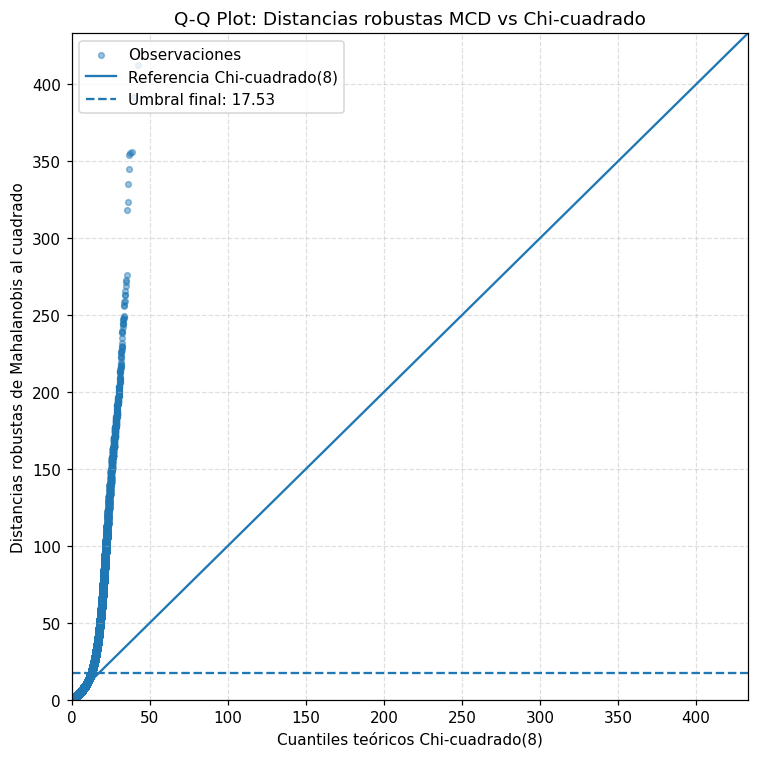

Resumen versión actual
es_outlier_actual
False    335393
True      48851
NaN          77
Name: count, dtype: int64
Total outliers: 48851


In [34]:
# ============================================================
# CLASE ROBUSTA PARA DETECCIÓN MULTIVARIADA DE OUTLIERS
# ============================================================

class RobustOutlierDetector:
    """
    Detector multivariado de valores atípicos basado en:
    
    - Estimación robusta MCD.
    - Distancia robusta de Mahalanobis.
    - Evaluación de normalidad multivariada mediante Henze-Zirkler.
    - Umbral teórico Chi-cuadrado o umbral empírico por bootstrap.
    
    bootstrap_mode:
        - "actual": reproduce la lógica usada originalmente.
        - "corrected": alternativa corregida, donde el percentil se estima
          sobre distancias bootstrap internas.
    """

    def __init__(
        self,
        variables: list,
        target_column: str = None,
        percentile: float = 97.5,
        b_simulations: int = 1000,
        force_bootstrap: bool = False,
        bootstrap_mode: str = "actual",
        evaluar_normalidad: bool = False,
        random_state: int = 42,
        n_jobs: int = -1
    ):
        self.variables = variables
        self.target_column = target_column
        self.percentile = percentile
        self.b_simulations = b_simulations
        self.force_bootstrap = force_bootstrap
        self.bootstrap_mode = bootstrap_mode
        self.evaluar_normalidad = evaluar_normalidad
        self.random_state = random_state
        self.n_jobs = n_jobs

        self.mcd_model_ = None
        self.features_names_ = None
        self.hz_results_ = None
        self.final_threshold_ = None
        self.method_used_ = None
        self.t2_distances_ = None
        self.X_index_ = None

    # ------------------------------------------------------------
    # Preparación de variables numéricas
    # ------------------------------------------------------------

    def _isolate_numeric_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Selecciona únicamente las variables cuantitativas definidas.
        Se asume que los nulos ya fueron tratados previamente.
        """

        missing_cols = [col for col in self.variables if col not in df.columns]

        if missing_cols:
            raise ValueError(f"Estas variables no existen en el DataFrame: {missing_cols}")

        X_numeric = df[self.variables].copy()

        if self.target_column is not None:
            X_numeric = X_numeric.drop(columns=[self.target_column], errors='ignore')

        columnas_a_ignorar = [
            'T2_Hotelling',
            'T2_Final',
            'es_outlier',
            'es_outlier_bootstrap'
        ]

        X_numeric = X_numeric.drop(columns=columnas_a_ignorar, errors='ignore')

        X_numeric = (
            X_numeric
            .apply(pd.to_numeric, errors='coerce')
            .astype(float)
        )

        X_numeric = X_numeric.dropna()

        return X_numeric

    # ------------------------------------------------------------
    # Bootstrap actual
    # ------------------------------------------------------------

    @staticmethod
    def _bootstrap_worker_actual(X_matrix: np.ndarray, seed: int, percentile: float):
        """
        Alternativa actual:
        - Se remuestrea X.
        - Se ajusta MCD sobre la muestra bootstrap.
        - Se calculan distancias sobre la muestra original.
        
        Esta versión reproduce la lógica inicial.
        """

        X_boot = resample(X_matrix, replace=True, random_state=seed)

        try:
            mcd_boot = MinCovDet(random_state=seed).fit(X_boot)
            distances = mcd_boot.mahalanobis(X_matrix)
            return np.percentile(distances, percentile)

        except Exception:
            return None

    # ------------------------------------------------------------
    # Bootstrap corregido
    # ------------------------------------------------------------

    @staticmethod
    def _bootstrap_worker_corrected(X_matrix: np.ndarray, seed: int, percentile: float):
        """
        Alternativa corregida:
        - Se remuestrea X.
        - Se ajusta MCD sobre la muestra bootstrap.
        - Se calculan distancias sobre la misma muestra bootstrap.
        - Se obtiene el percentil empírico interno.
        
        Esta versión estima un umbral empírico más coherente con la
        distribución bootstrap de las distancias robustas.
        """

        X_boot = resample(X_matrix, replace=True, random_state=seed)

        try:
            mcd_boot = MinCovDet(random_state=seed).fit(X_boot)
            distances_boot = mcd_boot.mahalanobis(X_boot)
            return np.percentile(distances_boot, percentile)

        except Exception:
            return None

    # ------------------------------------------------------------
    # Ejecución bootstrap
    # ------------------------------------------------------------

    def _execute_bootstrap(self, X_matrix: np.ndarray):
        """
        Ejecuta bootstrap paralelo según el modo seleccionado.
        """

        if self.bootstrap_mode not in ["actual", "corrected"]:
            raise ValueError("bootstrap_mode debe ser 'actual' o 'corrected'.")

        print(
            f"Ejecutando Bootstrap | "
            f"B={self.b_simulations} | "
            f"modo={self.bootstrap_mode} | "
            f"n_jobs={self.n_jobs}"
        )

        rng = np.random.RandomState(self.random_state)
        seeds = rng.randint(0, 1_000_000, size=self.b_simulations)

        if self.bootstrap_mode == "actual":
            worker = self._bootstrap_worker_actual
            self.method_used_ = "Bootstrap Empírico Actual"

        else:
            worker = self._bootstrap_worker_corrected
            self.method_used_ = "Bootstrap Empírico Corregido"

        results = Parallel(n_jobs=self.n_jobs)(
            delayed(worker)(X_matrix, int(seed), self.percentile)
            for seed in seeds
        )

        valid_results = [r for r in results if r is not None]

        if len(valid_results) == 0:
            raise RuntimeError("Todas las simulaciones bootstrap fallaron.")

        return np.median(valid_results)

    # ------------------------------------------------------------
    # Ajuste del detector
    # ------------------------------------------------------------

    def fit(self, df: pd.DataFrame):
        """
        Ajusta el detector robusto:
        - Selecciona variables.
        - Estima MCD.
        - Calcula distancias robustas.
        - Evalúa normalidad multivariada.
        - Define umbral de corte.
        """

        X_numeric = self._isolate_numeric_features(df)

        self.X_index_ = X_numeric.index
        self.features_names_ = X_numeric.columns.tolist()

        p_features = len(self.features_names_)
        X_matrix = X_numeric.values

        if p_features < 2:
            raise ValueError("Se requieren al menos 2 variables cuantitativas.")

        if X_matrix.shape[0] <= p_features:
            raise ValueError("El número de observaciones debe ser mayor que el número de variables.")

        # Ajuste MCD robusto
        self.mcd_model_ = MinCovDet(random_state=self.random_state).fit(X_matrix)

        # Distancias robustas de Mahalanobis al cuadrado
        self.t2_distances_ = self.mcd_model_.mahalanobis(X_matrix)

        # Evaluación de normalidad multivariada
        if self.evaluar_normalidad:

            self.hz_results_ = pg.multivariate_normality(
                X_numeric,
                alpha=0.05
            )

            is_normal = self.hz_results_.normal

            print(f"Normalidad multivariada Henze-Zirkler: {is_normal}")
            print(f"p-valor HZ: {self.hz_results_.pval:.4e}")

        else:

            self.hz_results_ = None
            is_normal = False

            print("Normalidad multivariada: NO EVALUADA")

        print("============================================================")
        print("DIAGNÓSTICO ESTADÍSTICO MULTIVARIADO")
        print("============================================================")
        print(f"Variables analizadas: {p_features}")
        print(f"Registros analizados: {X_matrix.shape[0]}")

        if self.evaluar_normalidad:

            print(f"Normalidad multivariada Henze-Zirkler: {is_normal}")
            print(f"p-valor HZ: {self.hz_results_.pval:.4e}")

        else:

            print("Normalidad multivariada: NO EVALUADA")

        # Decisión de umbral
# ============================================================
# DECISIÓN DEL UMBRAL
# ============================================================

        if self.force_bootstrap:

            self.final_threshold_ = self._execute_bootstrap(X_matrix)

        elif self.evaluar_normalidad:

            if not is_normal:

                self.final_threshold_ = self._execute_bootstrap(X_matrix)

            else:

                self.method_used_ = "Teórico Chi-cuadrado"

                self.final_threshold_ = stats.chi2.ppf(
                    self.percentile / 100.0,
                    df=p_features
                )

        else:

            self.method_used_ = "Teórico Chi-cuadrado"

            self.final_threshold_ = stats.chi2.ppf(
                self.percentile / 100.0,
                df=p_features
            )

        print(f"Método de umbral: {self.method_used_}")
        print(f"Percentil usado: {self.percentile}")
        print(f"Umbral final: {self.final_threshold_:.4f}")
        print("============================================================\n")

        return self

    # ------------------------------------------------------------
    # Predicción de outliers
    # ------------------------------------------------------------

    def predict(self, df: pd.DataFrame) -> pd.Series:
        """
        Clasifica observaciones como outliers o no outliers.
        Retorna una Serie booleana alineada con el índice original.
        """

        if self.mcd_model_ is None:
            raise RuntimeError("Debes ejecutar .fit() antes de .predict().")

        X_numeric = (
            df[self.features_names_]
            .apply(pd.to_numeric, errors='coerce')
            .astype(float)
            .dropna()
        )

        distances = self.mcd_model_.mahalanobis(X_numeric.values)
        outlier_flag = distances > self.final_threshold_

        return pd.Series(outlier_flag, index=X_numeric.index, name="es_outlier")

    # ------------------------------------------------------------
    # Distancias
    # ------------------------------------------------------------

    def get_distances(self) -> pd.Series:
        """
        Retorna las distancias robustas de Mahalanobis calculadas en fit().
        """

        if self.t2_distances_ is None:
            raise RuntimeError("No hay distancias calculadas. Ejecuta .fit() primero.")

        return pd.Series(
            self.t2_distances_,
            index=self.X_index_,
            name="T2_Mahalanobis_MCD"
        )

    # ------------------------------------------------------------
    # Q-Q Plot
    # ------------------------------------------------------------

    def plot_qq_plot(self):
        """
        Q-Q Plot de distancias robustas frente a cuantiles Chi-cuadrado.
        """

        if self.t2_distances_ is None:
            raise RuntimeError("No hay distancias calculadas. Ejecuta .fit() primero.")

        d_sq_sorted = np.sort(self.t2_distances_)
        n_obs = len(d_sq_sorted)
        p_df = len(self.features_names_)

        probs = (np.arange(1, n_obs + 1) - 0.5) / n_obs
        chi2_theoretical = stats.chi2.ppf(probs, df=p_df)

        lim = max(chi2_theoretical.max(), d_sq_sorted.max()) * 1.05

        fig, ax = plt.subplots(figsize=(7, 7), dpi=110)

        ax.scatter(
            chi2_theoretical,
            d_sq_sorted,
            alpha=0.45,
            s=14,
            label="Observaciones"
        )

        ax.plot(
            [0, lim],
            [0, lim],
            linewidth=1.5,
            label=f"Referencia Chi-cuadrado({p_df})"
        )

        ax.axhline(
            self.final_threshold_,
            linestyle="--",
            linewidth=1.5,
            label=f"Umbral final: {self.final_threshold_:.2f}"
        )

        ax.set_xlabel(f"Cuantiles teóricos Chi-cuadrado({p_df})")
        ax.set_ylabel("Distancias robustas de Mahalanobis al cuadrado")
        ax.set_title("Q-Q Plot: Distancias robustas MCD vs Chi-cuadrado")

        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)

        ax.legend(loc="upper left")
        ax.grid(True, linestyle="--", alpha=0.4)

        plt.tight_layout()
        plt.show()


# ============================================================
# USO DEL DETECTOR
# ============================================================

# ------------------------------------------------------------
# Opción A: versión actual del bootstrap
# ------------------------------------------------------------
data_outliers = df_imputado.copy() #o los impuatdos o el limpio, dependiendo del análisis que se quiera hacer
detector_actual = RobustOutlierDetector(
    variables=variables_cuantitativas,
    percentile=97.5,
    b_simulations=1000,
    force_bootstrap=False,
    #bootstrap_mode=False,
    evaluar_normalidad=False,
    random_state=42,
    n_jobs=1
)

detector_actual.fit(data_outliers)

data_outliers["T2_Mahalanobis_MCD_actual"] = detector_actual.get_distances()
data_outliers["es_outlier_actual"] = detector_actual.predict(data_outliers)

detector_actual.plot_qq_plot()

print("Resumen versión actual")
print(data_outliers["es_outlier_actual"].value_counts(dropna=False))
print(f"Total outliers: {data_outliers['es_outlier_actual'].sum()}")




In [35]:
# ============================================================
# ASEGURAR MÁSCARA BOOLEANA SIN NaN
# ============================================================

mask_outliers = (
    data_outliers["es_outlier_actual"]
    .fillna(False)
    .astype(bool)
)

# ============================================================
# SOLO OUTLIERS MULTIVARIADOS
# ============================================================

df_outliers_multivariados = (
    data_outliers
    .loc[mask_outliers]
    .copy()
)

# ============================================================
# DATASET SIN OUTLIERS MULTIVARIADOS
# ============================================================

df_sin_outliers_multivariados = (
    data_outliers
    .loc[~mask_outliers]
    .copy()
)

print("Total registros:", len(data_outliers))
print("Outliers multivariados:", len(df_outliers_multivariados))
print("Sin outliers multivariados:", len(df_sin_outliers_multivariados))

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15144\853761869.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


Total registros: 384321
Outliers multivariados: 48851
Sin outliers multivariados: 335470


In [40]:
datasets = {
    "Original": data_outliers,
    "Sin_atipicos_multivariados": df_sin_outliers_multivariados
}

for nombre, datos in datasets.items():

    # ---------------------------------------
    # Variables numéricas disponibles
    # ---------------------------------------

    vars_disp = [
        v for v in variables_cuantitativas
        if v in datos.columns
    ]

    # ---------------------------------------
    # Correlación de Pearson
    # ---------------------------------------

    corr = (
        datos[vars_disp]
        .corr(method="pearson")
    )

    print(f"\nCorrelación de Pearson - {nombre}")
    display(corr.round(3))


Correlación de Pearson - Original


,PESO_GRAMOS,NUM_CONSULTAS_PRENAT,EDAD_MADRE,NUM_HIJOS_NACIDOS_VIVOS,NUM_EMBARAZOS,EDAD_PADRE,TIEMPO_GESTACION,TALLA_CENTIMETROS
PESO_GRAMOS,1.000,0.103,0.033,0.008,0.020,0.034,0.732,0.806
NUM_CONSULTAS_PRENAT,0.103,1.000,0.319,-0.128,-0.082,0.233,0.095,0.042
EDAD_MADRE,0.033,0.319,1.000,0.340,0.370,0.638,-0.028,-0.017
NUM_HIJOS_NACIDOS_VIVOS,0.008,-0.128,0.340,1.000,0.845,0.243,-0.055,0.004
NUM_EMBARAZOS,0.020,-0.082,0.370,0.845,1.000,0.261,-0.047,0.008
EDAD_PADRE,0.034,0.233,0.638,0.243,0.261,1.000,-0.015,-0.001
TIEMPO_GESTACION,0.732,0.095,-0.028,-0.055,-0.047,-0.015,1.000,0.721
TALLA_CENTIMETROS,0.806,0.042,-0.017,0.004,0.008,-0.001,0.721,1.000



Correlación de Pearson - Sin_atipicos_multivariados


,PESO_GRAMOS,NUM_CONSULTAS_PRENAT,EDAD_MADRE,NUM_HIJOS_NACIDOS_VIVOS,NUM_EMBARAZOS,EDAD_PADRE,TIEMPO_GESTACION,TALLA_CENTIMETROS
PESO_GRAMOS,1.000,0.073,0.066,0.043,0.051,0.064,0.587,0.717
NUM_CONSULTAS_PRENAT,0.073,1.000,0.368,-0.083,-0.037,0.301,0.038,-0.020
EDAD_MADRE,0.066,0.368,1.000,0.314,0.346,0.729,-0.017,-0.003
NUM_HIJOS_NACIDOS_VIVOS,0.043,-0.083,0.314,1.000,0.801,0.254,-0.052,0.030
NUM_EMBARAZOS,0.051,-0.037,0.346,0.801,1.000,0.274,-0.043,0.029
EDAD_PADRE,0.064,0.301,0.729,0.254,0.274,1.000,-0.007,0.009
TIEMPO_GESTACION,0.587,0.038,-0.017,-0.052,-0.043,-0.007,1.000,0.502
TALLA_CENTIMETROS,0.717,-0.020,-0.003,0.030,0.029,0.009,0.502,1.000


los outliers multivariados no corresponden necesariamente a errores de medición, sino que podrían representar observaciones reales clínicamente extremas (prematuros severos, neonatos de muy bajo peso, tallas inusualmente bajas o combinaciones poco frecuentes de variables). Por esta razón, eliminarlos implica una pérdida de información epidemiológicamente relevante y modifica parcialmente la estructura estadística subyacente del fenómeno. En consecuencia, para fines descriptivos y de reducción dimensional, existe una justificación sólida para conservar el conjunto df_limpio y utilizar los outliers multivariados principalmente como herramienta diagnóstica y de sensibilidad, más que como criterio automático de exclusión.

In [41]:
# ============================================================
# DESCRIPTIVOS COMPARATIVOS
# df, df_limpio y df_sin_atipicos
# ============================================================

datasets = {
    "Original": data_outliers,
    "Sin_atipicos_multivariados": df_sin_outliers_multivariados
}

resumen_descriptivo = []

for nombre, datos in datasets.items():

    desc = (
        datos[variables_cuantitativas]
        .describe()
        .T
        .reset_index()
        .rename(columns={"index": "variable"})
    )

    desc["dataset"] = nombre

    resumen_descriptivo.append(desc)

resumen_descriptivo = pd.concat(
    resumen_descriptivo,
    ignore_index=True
)

# Reordenar columnas
cols = [
    "dataset",
    "variable",
    "count",
    "mean",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
]

resumen_descriptivo = resumen_descriptivo[cols]

display(resumen_descriptivo)

,dataset,variable,count,mean,std,min,25%,50%,75%,max
0,Original,PESO_GRAMOS,384244.0,2935.079681,498.211374,345.0,2680.0,2980.0,3255.0,5325.0
1,Original,NUM_CONSULTAS_PRENAT,384321.0,6.654721,2.930342,0.0,5.0,7.0,8.0,25.0
2,Original,EDAD_MADRE,384321.0,27.876710,6.318831,11.0,23.0,28.0,32.0,54.0
3,Original,NUM_HIJOS_NACIDOS_VIVOS,384321.0,1.691266,0.884176,1.0,1.0,1.0,2.0,14.0
4,Original,NUM_EMBARAZOS,384321.0,1.915784,1.079296,1.0,1.0,2.0,2.0,15.0
5,Original,EDAD_PADRE,384321.0,30.874490,7.534633,0.0,26.0,30.0,35.0,80.0
6,Original,TIEMPO_GESTACION,384321.0,38.017145,1.906346,20.0,37.0,38.0,39.0,43.0
7,Original,TALLA_CENTIMETROS,384321.0,49.207626,2.839713,17.0,48.0,50.0,51.0,61.0
8,Sin_atipicos_multivariados,PESO_GRAMOS,335393.0,2993.225506,401.858716,1370.0,2730.0,3005.0,3265.0,4470.0
9,Sin_atipicos_multivariados,NUM_CONSULTAS_PRENAT,335470.0,6.754625,2.721906,0.0,5.0,7.0,8.0,18.0


La eliminación de los valores atípicos multivariados identificados mediante el estimador robusto MCD y la distancia de Mahalanobis produjo una reducción aproximada del 12.7% de las observaciones. Los cambios más notorios se observan en las variables directamente relacionadas con el desarrollo fetal y neonatal, particularmente peso al nacer, edad gestacional y talla neonatal. En especial, desaparecen prácticamente todos los nacimientos extremadamente prematuros y los recién nacidos con pesos y tallas extremas, generando una reducción importante de la variabilidad observada. Estos resultados sugieren que una proporción considerable de los outliers multivariados corresponde a casos clínicamente extremos pero plausibles, más que a errores evidentes de registro. En consecuencia, aunque la eliminación de estos individuos genera una muestra más homogénea, también implica la pérdida de información epidemiológicamente relevante para el estudio del bajo peso al nacer y sus factores asociados.